In [1]:
import json
from pathlib import Path
from typing import Dict, List

from model_ranking import (
    plot_alpha_sweep_specific_norm,
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,
)

INFO: P [MainThread] 2025-10-17 11:41:05,655 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
performance_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice/transfer_performance_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice/transfer_Gauss_a001-a005_Forg_05f_05b_ARE_scores.json
Processing: Gauss_Consistency_a001-a005
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


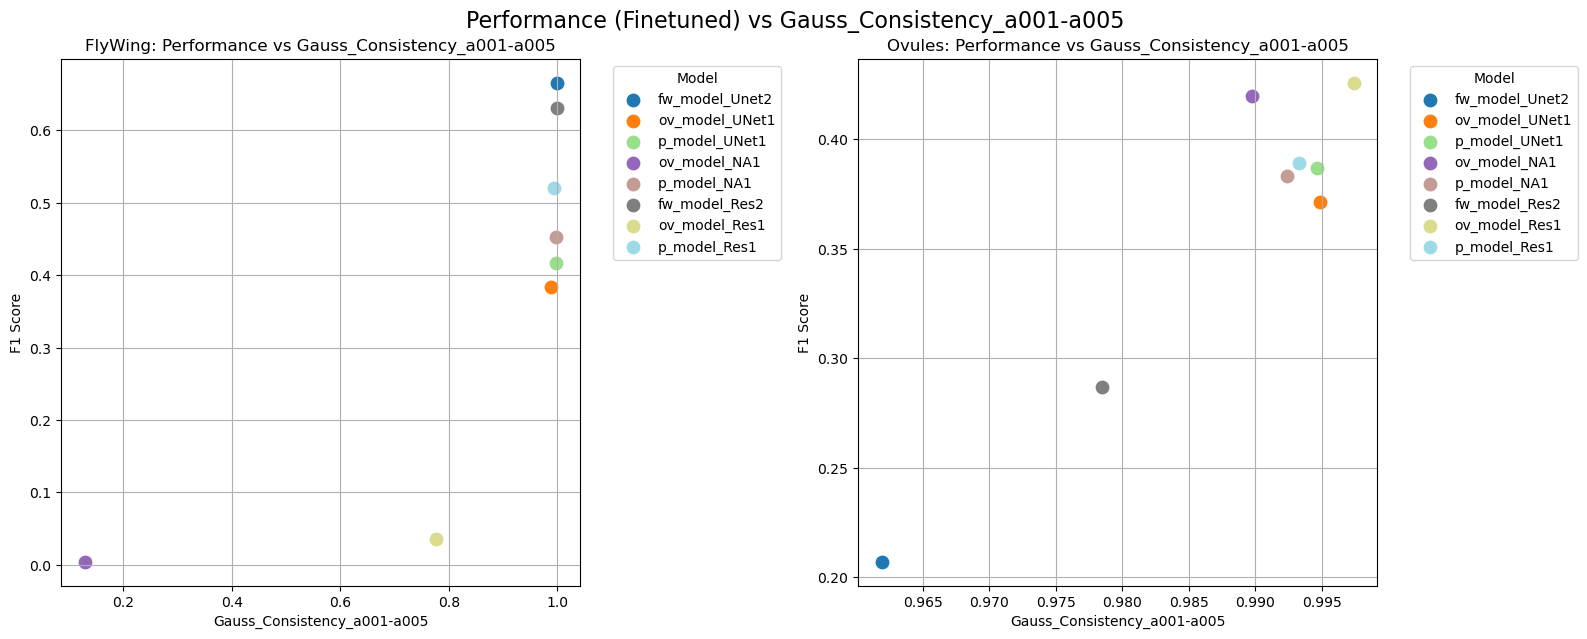

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.78     0.02    0.9        0.01  0.79      0.0
     Ovules   0.95     0.00    0.6        0.13  0.43      0.2
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice/transfer_Gauss_a005-a01_Forg_05f_05b_ARE_scores.json
Processing: Gauss_Consistency_a005-a01
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


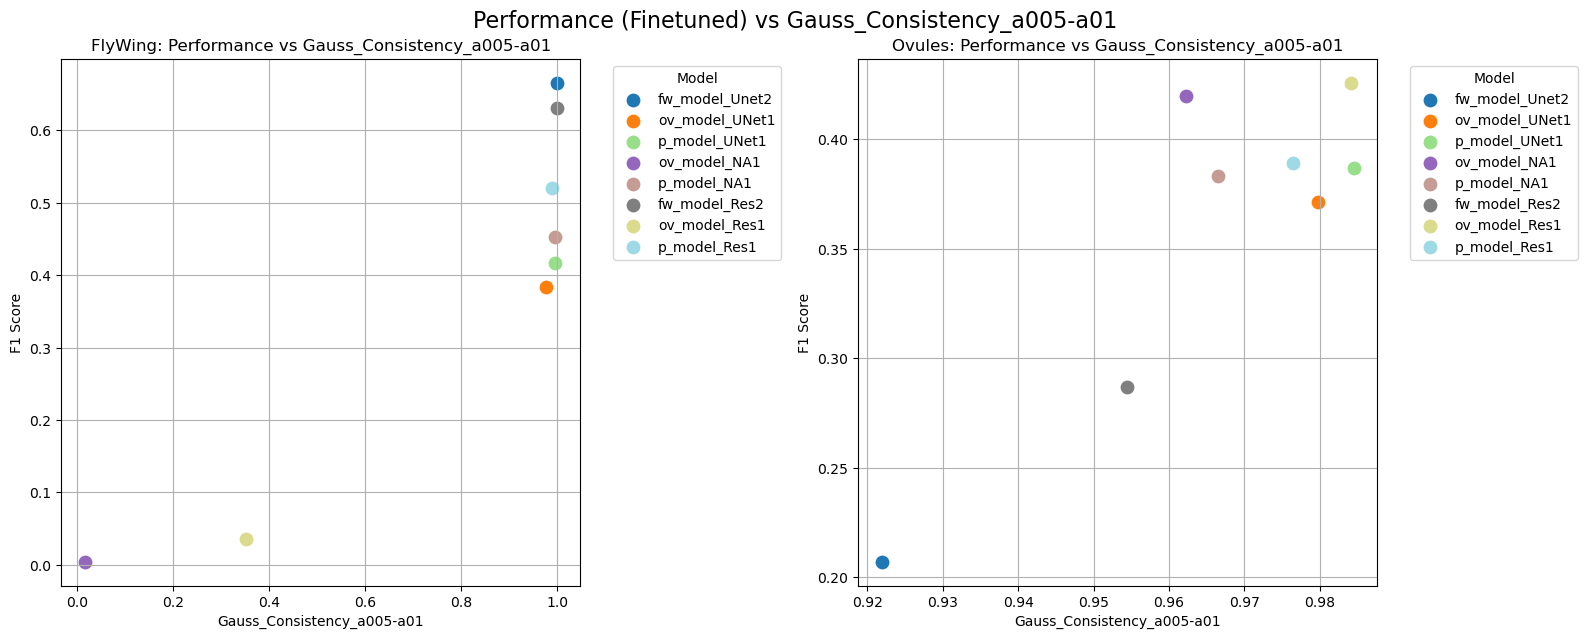

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.91      0.0   0.90        0.01  0.79     0.01
     Ovules   0.87      0.0   0.57        0.16  0.43     0.18
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice/transfer_Gauss_a01-a015_Forg_05f_05b_ARE_scores.json
Processing: Gauss_Consistency_a01-a015
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


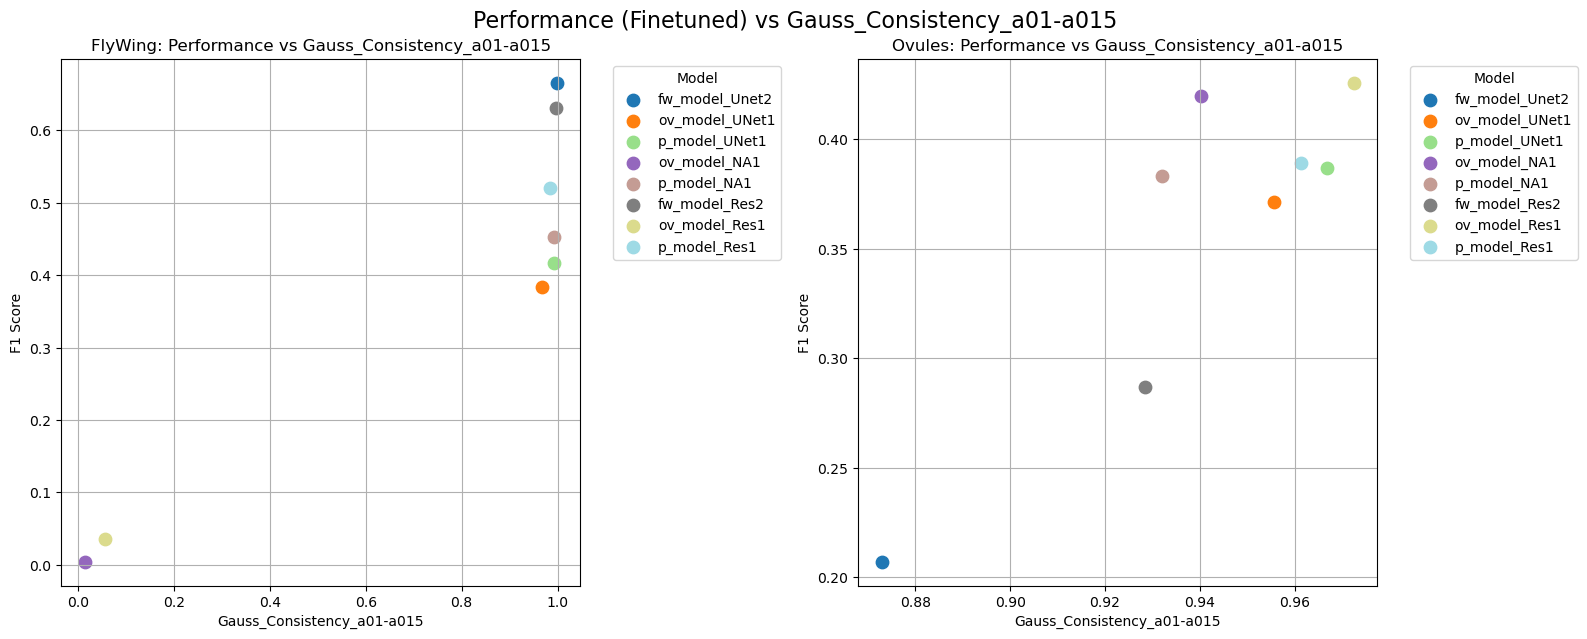

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.92      0.0   0.90        0.00  0.79     0.01
     Ovules   0.88      0.0   0.79        0.03  0.64     0.04
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice/transfer_Gauss_a015-a02_Forg_05f_05b_ARE_scores.json
Processing: Gauss_Consistency_a015-a02
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


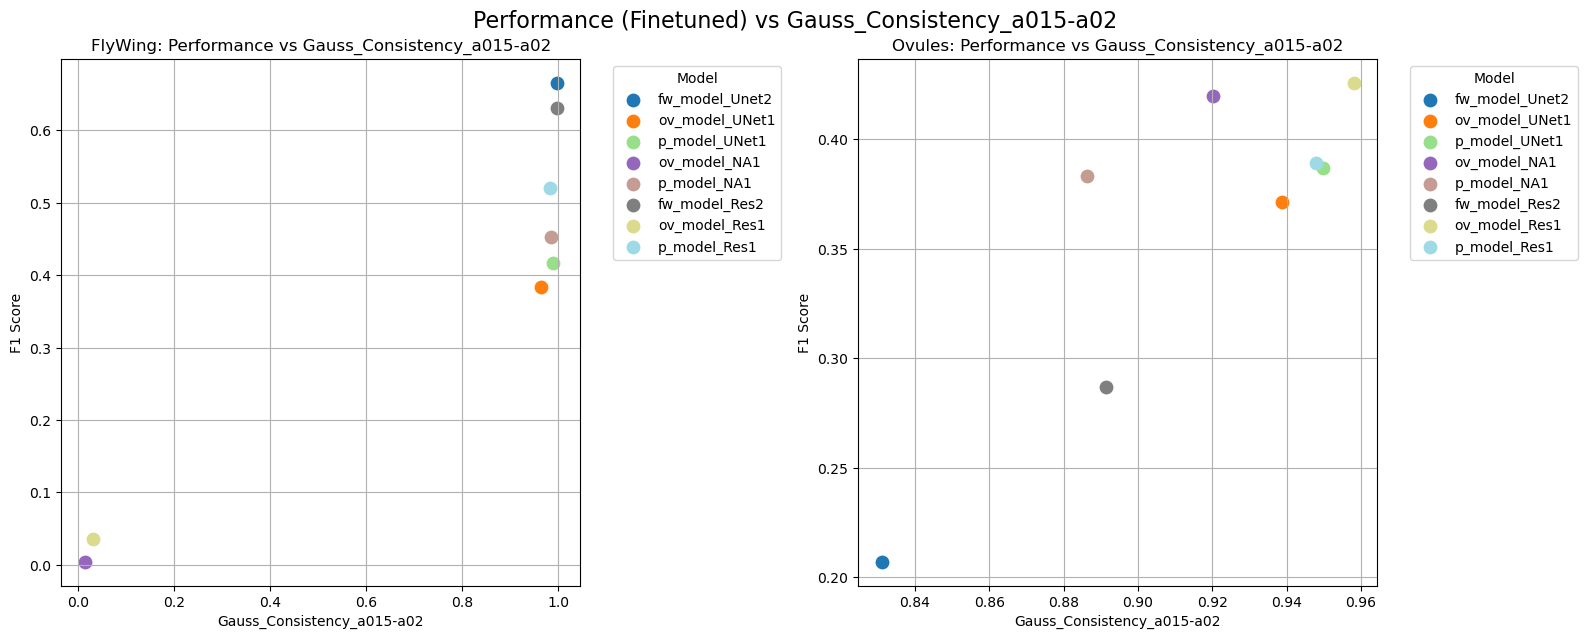

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.93     0.00   0.90        0.00  0.79     0.01
     Ovules   0.85     0.01   0.74        0.05  0.57     0.07
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice/transfer_Gauss_a02-a025_Forg_05f_05b_ARE_scores.json
Processing: Gauss_Consistency_a02-a025
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


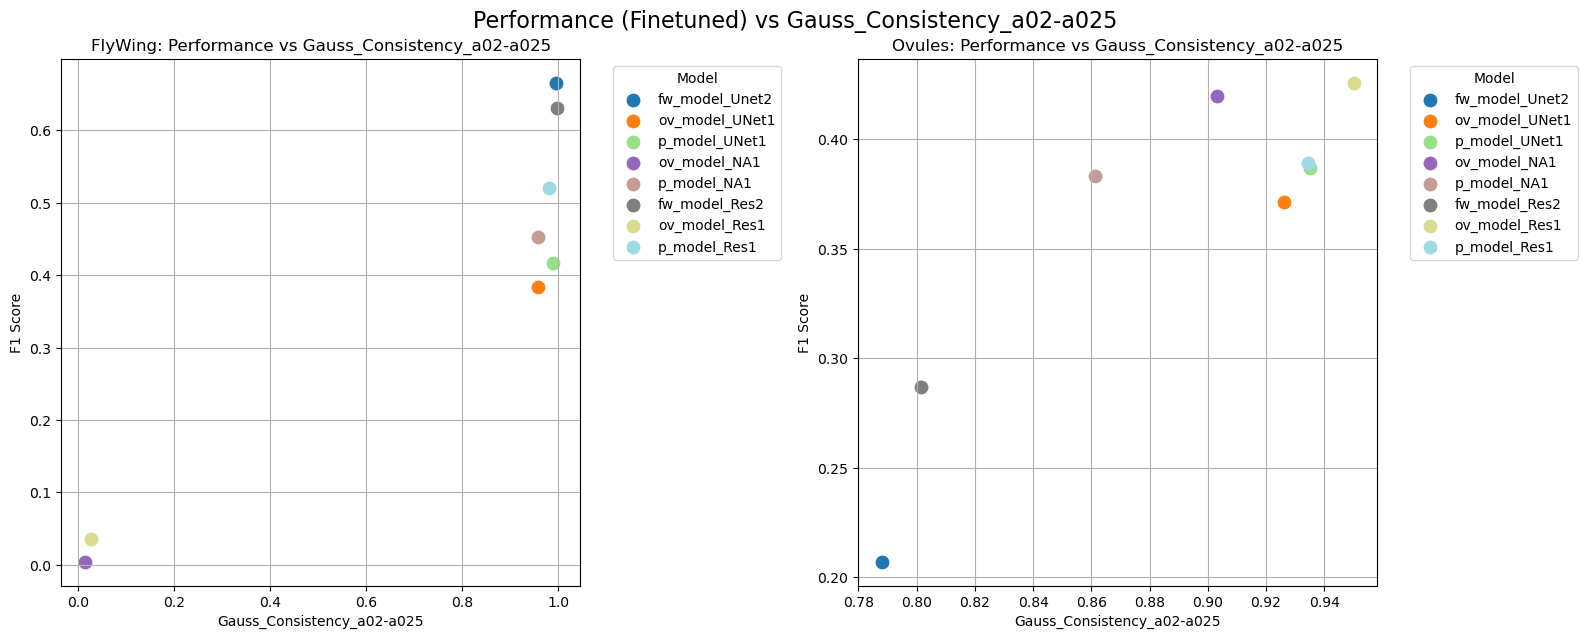

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.93      0.0   0.86        0.01  0.71     0.02
     Ovules   0.88      0.0   0.79        0.02  0.64     0.02


In [4]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice"
selected_augmentations = ["a001-a005", "a005-a01", "a01-a015", "a015-a02", "a02-a025"]

for aug in selected_augmentations:
    file_name = f"transfer_Gauss_{aug}_Forg_05f_05b_ARE_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_scores,
            transfer_scores=consistency_scores,
            transfer_metric=f"Gauss_Consistency_{aug}",
            invert_transfer_metric=True,
            finetuned=True
        )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=performance_scores,
        invert_transfer_metric=True,
    )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
            
        

# Weighted Average

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg/transfer_Gauss_a001-a005_Forg_05f_05b_ARE_scores.json
Processing: Gauss_Consistency_a001-a005
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


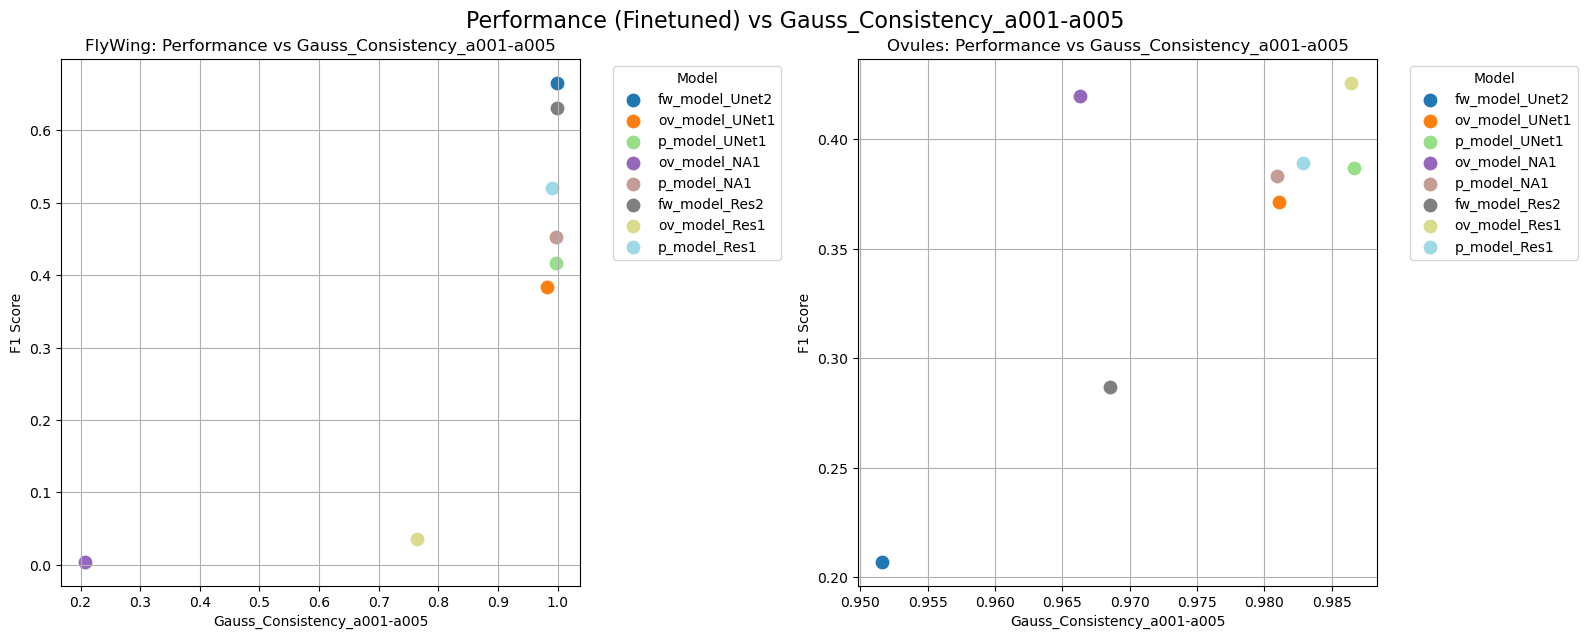

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.80     0.02   0.90        0.00  0.79     0.01
     Ovules   0.78     0.02   0.52        0.19  0.43     0.21
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg/transfer_Gauss_a005-a01_Forg_05f_05b_ARE_scores.json
Processing: Gauss_Consistency_a005-a01
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


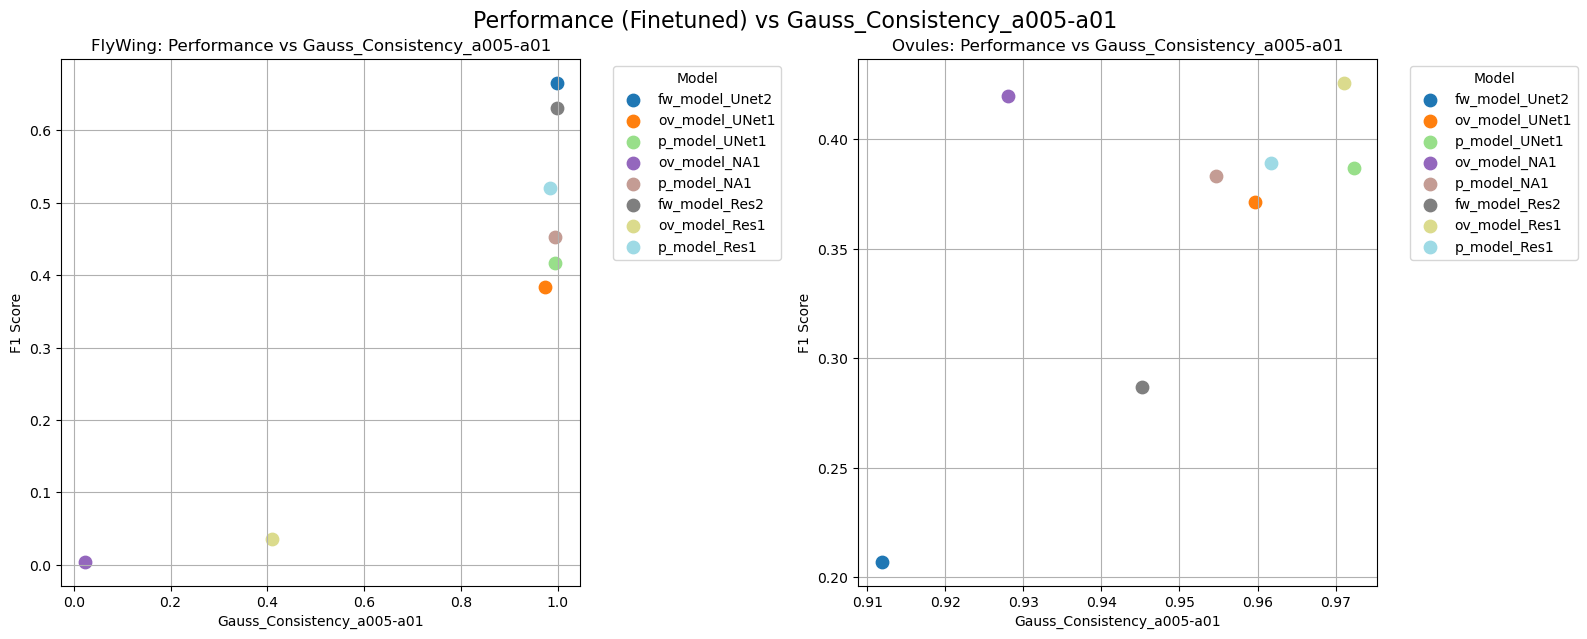

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.90     0.00   0.90         0.0  0.79     0.01
     Ovules   0.67     0.07   0.52         0.2  0.43     0.18
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg/transfer_Gauss_a01-a015_Forg_05f_05b_ARE_scores.json
Processing: Gauss_Consistency_a01-a015
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


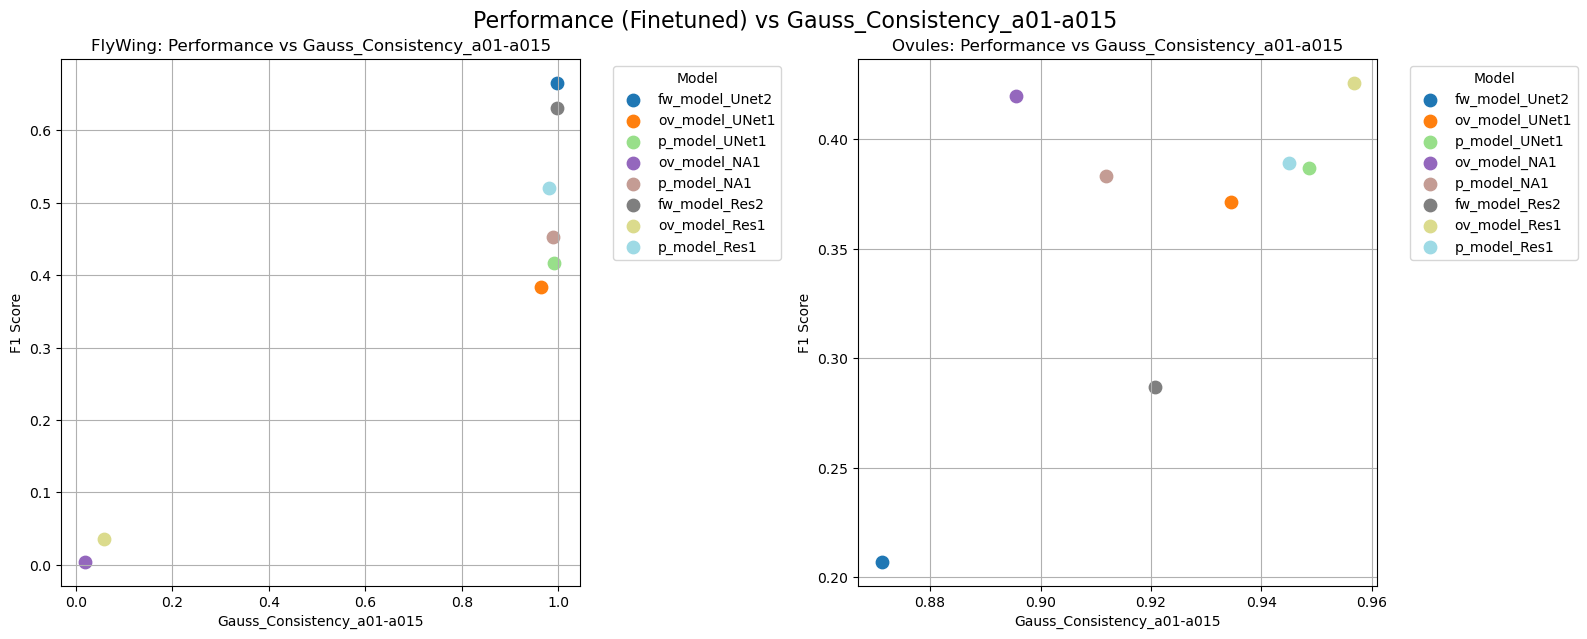

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.93     0.00   0.90        0.01  0.79     0.01
     Ovules   0.65     0.08   0.55        0.15  0.43     0.17
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg/transfer_Gauss_a015-a02_Forg_05f_05b_ARE_scores.json
Processing: Gauss_Consistency_a015-a02
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


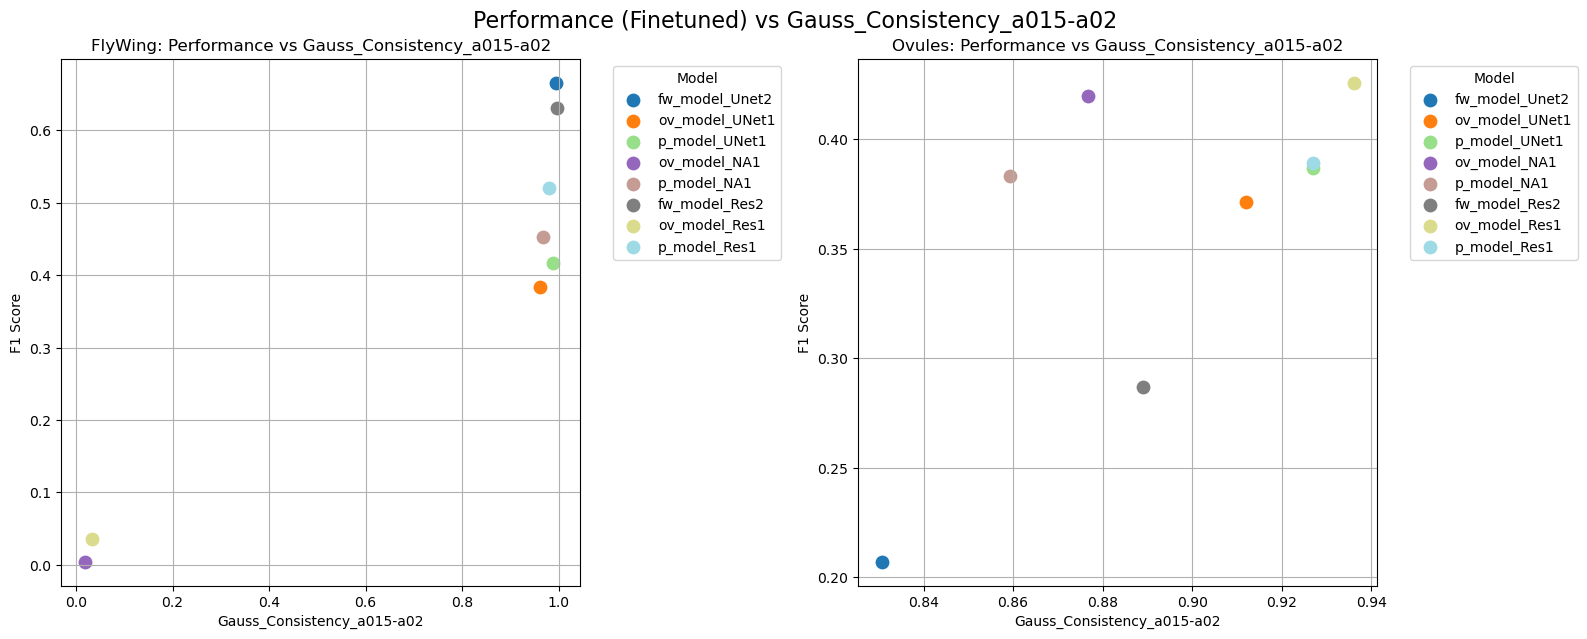

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.93     0.00   0.90        0.01  0.79     0.01
     Ovules   0.67     0.07   0.62        0.11  0.50     0.12
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg/transfer_Gauss_a02-a025_Forg_05f_05b_ARE_scores.json
Processing: Gauss_Consistency_a02-a025
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


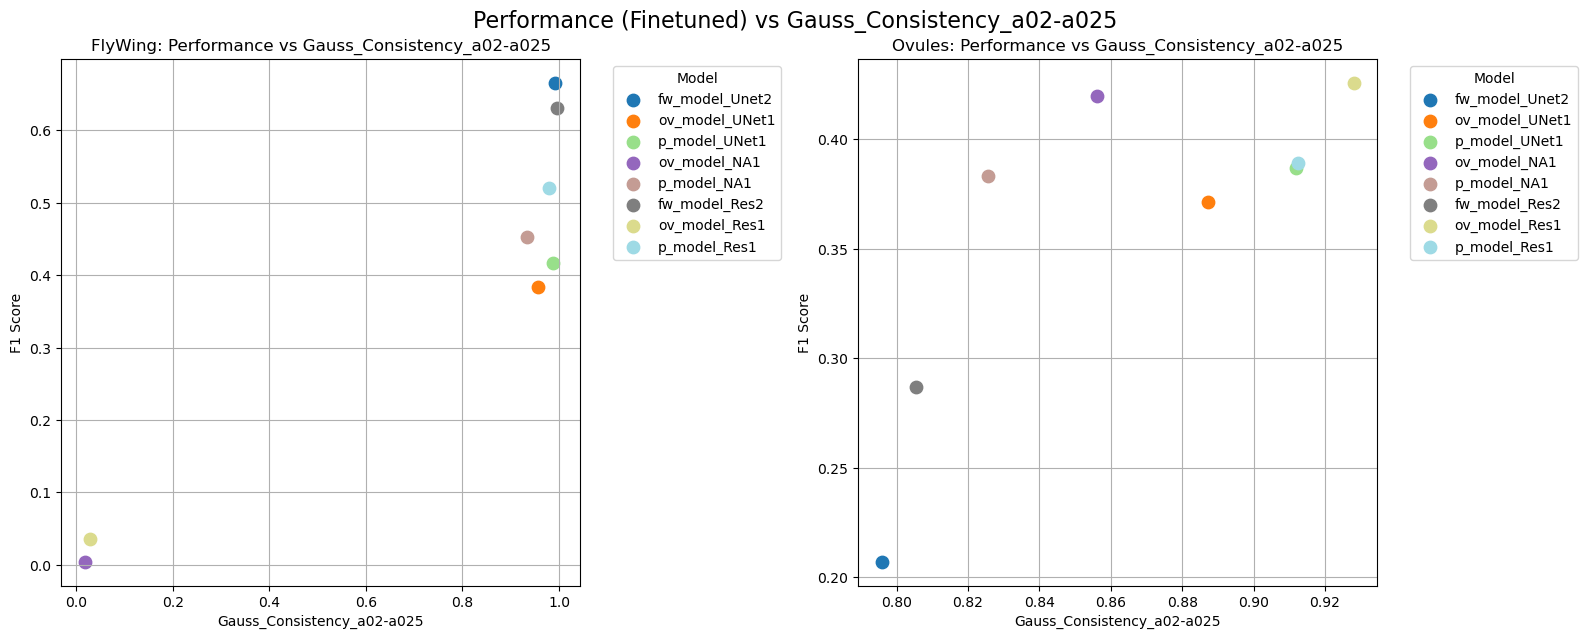

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.93     0.00   0.86        0.01  0.71     0.01
     Ovules   0.76     0.03   0.81        0.02  0.71     0.02


In [5]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg"
selected_augmentations = ["a001-a005", "a005-a01", "a01-a015", "a015-a02", "a02-a025"]

for aug in selected_augmentations:
    file_name = f"transfer_Gauss_{aug}_Forg_05f_05b_ARE_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_scores,
        transfer_scores=consistency_scores,
        transfer_metric=f"Gauss_Consistency_{aug}",
        invert_transfer_metric=True,
        finetuned=True
    )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=performance_scores,
        invert_transfer_metric=True,
    )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
            
        